In [29]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [30]:
import os

print(os.getcwd())

C:\Users\shivk


In [31]:
import pandas as pd

df = pd.read_csv("iris.csv")

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [32]:
print(df.shape)
print(df.columns)
print(df.info())

(150, 5)
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [33]:
# Display unique species
print(df["species"].unique())

# Count the number of samples in each class
print(df["species"].value_counts())

['setosa' 'versicolor' 'virginica']
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [34]:
# Remove Virginica
df = df[df["species"] != "virginica"]

# Reset row numbers
df = df.reset_index(drop=True)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [35]:
print(df["species"].unique())

['setosa' 'versicolor']


In [36]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
Name: count, dtype: int64


In [37]:
print(y[:10] == "setosa")

[False False False False False False False False False False]


In [38]:
# Select the required feature columns
X = df[["petal_length", "petal_width"]]

# Convert the DataFrame to a NumPy array
X = X.to_numpy()
print(X.shape)

(100, 2)


In [39]:
# Select the target column
y = df["species"]

# Convert it to a NumPy array
y = y.to_numpy()
print(y[:10])

['setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa']


In [40]:
import numpy as np

y = np.where(y == "setosa", -1, 1)
print(y[:10])

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [41]:
print(y[45:55])

[-1 -1 -1 -1 -1  1  1  1  1  1]


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)
print(X[:5])

[[-1.01297765 -1.04211089]
 [-1.01297765 -1.04211089]
 [-1.08231219 -1.04211089]
 [-0.94364311 -1.04211089]
 [-1.01297765 -1.04211089]]


In [43]:
print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (100, 2)
Target Vector Shape  : (100,)


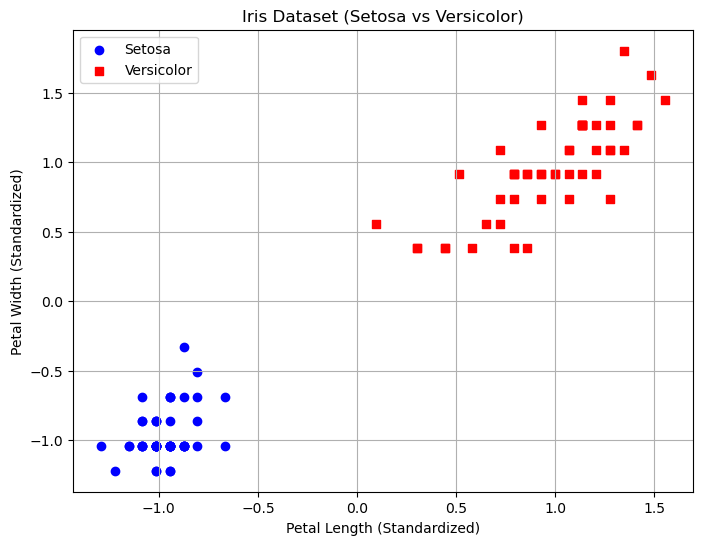

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X[y==-1,0],
    X[y==-1,1],
    color="blue",
    marker='o',
    label="Setosa"
)

plt.scatter(
    X[y==1,0],
    X[y==1,1],
    color="red",
    marker='s',
    label="Versicolor"
)

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Iris Dataset (Setosa vs Versicolor)")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
print("Feature matrix shape :", X.shape)
print("Target vector shape  :", y.shape)

print("\nFirst five feature vectors:")
print(X[:5])

In [ ]:
print("\nFirst five labels:")
print(y[:5])

Feature matrix shape : (100, 2)
Target vector shape  : (100,)

First five feature vectors:
[[-1.01297765 -1.04211089]
 [-1.01297765 -1.04211089]
 [-1.08231219 -1.04211089]
 [-0.94364311 -1.04211089]
 [-1.01297765 -1.04211089]]

First five labels:
[-1 -1 -1 -1 -1]


In [46]:
import numpy as np

class LinearSVM:
    
    def __init__(self, learning_rate=0.001, lambda_param=0.01, epochs=1000):
        """
        Initialize the SVM model.

        Parameters:
        learning_rate : Step size for gradient descent.
        lambda_param  : Regularization parameter.
        epochs        : Number of iterations over the dataset.
        """
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.epochs = epochs

        self.w = None
        self.b = None


    def fit(self, X, y):
        """
        Train the SVM using Gradient Descent.
        """

        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.w = np.zeros(n_features)
        self.b = 0


        # Gradient Descent
        for epoch in range(self.epochs):

            for idx, x_i in enumerate(X):

                # Check the SVM constraint
                condition = y[idx] * (np.dot(x_i, self.w) + self.b)

                if condition >= 1:
                    # Correctly classified
                    dw = 2 * self.lambda_param * self.w
                    db = 0

                else:
                    # Misclassified or inside the margin
                    dw = 2 * self.lambda_param * self.w - y[idx] * x_i
                    db = -y[idx]

                # Update parameters
                self.w = self.w - self.learning_rate * dw
                self.b = self.b - self.learning_rate * db


    def predict(self, X):
        """
        Predict class labels.
        """

        linear_output = np.dot(X, self.w) + self.b

        return np.sign(linear_output)

In [47]:
svm = LinearSVM(
    learning_rate=0.001,
    lambda_param=0.01,
    epochs=1000
)

In [48]:
svm.fit(X, y)

In [49]:
print("Weight Vector:")
print(svm.w)

print("\nBias:")
print(svm.b)

Weight Vector:
[1.05189686 0.9181348 ]

Bias:
0.33200000000000024


In [50]:
y_pred = svm.predict(X)
print(y_pred[:10])

[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]


In [51]:
accuracy = np.sum(y == y_pred) / len(y)

print(f"Accuracy : {accuracy * 100:.2f}%")

Accuracy : 100.00%


In [52]:
print(f"Decision Boundary:")
print(f"{svm.w[0]:.4f} * x1 + {svm.w[1]:.4f} * x2 + {svm.b:.4f} = 0")

Decision Boundary:
1.0519 * x1 + 0.9181 * x2 + 0.3320 = 0


In [53]:
sample = np.array([[4.5, 1.4]])

sample = scaler.transform(sample)

prediction = svm.predict(sample)

print(prediction)

[1.]


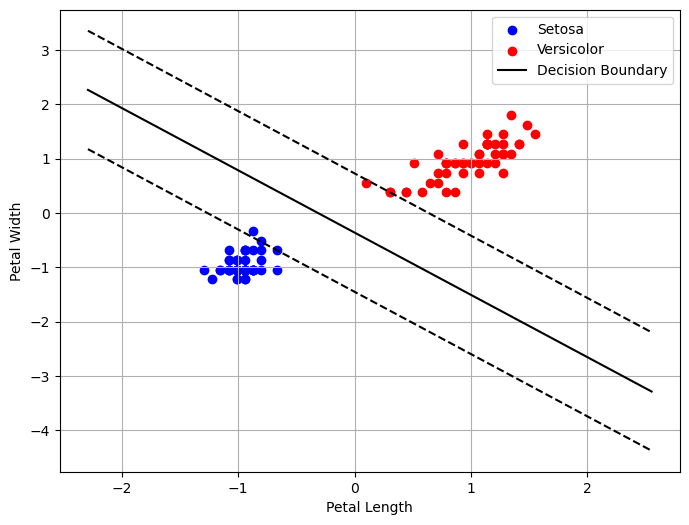

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(X[y==-1][:,0], X[y==-1][:,1], color='blue', label='Setosa')
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='red', label='Versicolor')

x1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)

x2 = -(svm.w[0]*x1 + svm.b)/svm.w[1]

margin_positive = -(svm.w[0]*x1 + svm.b - 1)/svm.w[1]
margin_negative = -(svm.w[0]*x1 + svm.b + 1)/svm.w[1]

plt.plot(x1, x2, 'k', label='Decision Boundary')
plt.plot(x1, margin_positive, 'k--')
plt.plot(x1, margin_negative, 'k--')

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.legend()
plt.grid(True)

plt.show()